# YOLO26n-seg Instance Segmentation Inference

This notebook demonstrates how to load the trained YOLO26n-seg model and run instance segmentation on a user-provided image path.

In [1]:
import os
import sys

# Working dir is notebooks/B2, so project root is 2 directories up
base_dir = os.path.dirname(os.path.dirname(os.getcwd()))

# Dynamically add the virtual environment's site-packages to sys.path
venv_site_packages = os.path.join(base_dir, "venv", "Lib", "site-packages")
if os.path.exists(venv_site_packages):
    sys.path.insert(0, venv_site_packages)
    print(f"Added virtual environment site-packages: {venv_site_packages}")
else:
    print(f"Warning: Virtual environment not found at {venv_site_packages}")

import matplotlib.pyplot as plt
from PIL import Image
from ultralytics import YOLO

model_path = os.path.join(base_dir, "model", "segmentation", "yolo26_seg", "weights", "best.pt")

print(f"Project root: {base_dir}")
print(f"Model path: {model_path}")
print(f"Model exists: {os.path.exists(model_path)}")

Added virtual environment site-packages: c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\venv\Lib\site-packages
Project root: c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU
Model path: c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\model\segmentation\yolo26_seg\weights\best.pt
Model exists: True


In [2]:
def predict_and_show(image_path):
    """
    Loads the model, runs instance segmentation on the input image,
    and visualizes the results with matplotlib.
    """
    if not os.path.exists(model_path):
        print(f"Error: Model weights not found at {model_path}")
        return
        
    if not os.path.exists(image_path):
        print(f"Error: Image file not found at {image_path}")
        return
        
    # Load model
    print(f"Loading model from {model_path}...")
    model = YOLO(model_path)
    
    # Run inference
    print(f"Running inference on {image_path}...")
    results = model.predict(source=image_path, conf=0.25)
    
    # Display results
    for i, r in enumerate(results):
        im_array = r.plot()  # plot a BGR numpy array of predictions
        im = Image.fromarray(im_array[..., ::-1])  # Convert BGR to RGB PIL Image
        
        plt.figure(figsize=(12, 12))
        plt.imshow(im)
        plt.title(f"Segmentation Results - Image {i+1}")
        plt.axis("off")
        plt.show()

Loading model from c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\model\segmentation\yolo26_seg\weights\best.pt...
Running inference on c:\Users\Admin\HUIT - Học Tập\Năm 3\DocU\data\test_seg\3.jpg...

image 1/1 c:\Users\Admin\HUIT - Hc Tp\Nm 3\DocU\data\test_seg\3.jpg: 608x640 1 CHIP_FRONT, 36.3ms
Speed: 7.8ms preprocess, 36.3ms inference, 1.7ms postprocess per image at shape (1, 3, 608, 640)


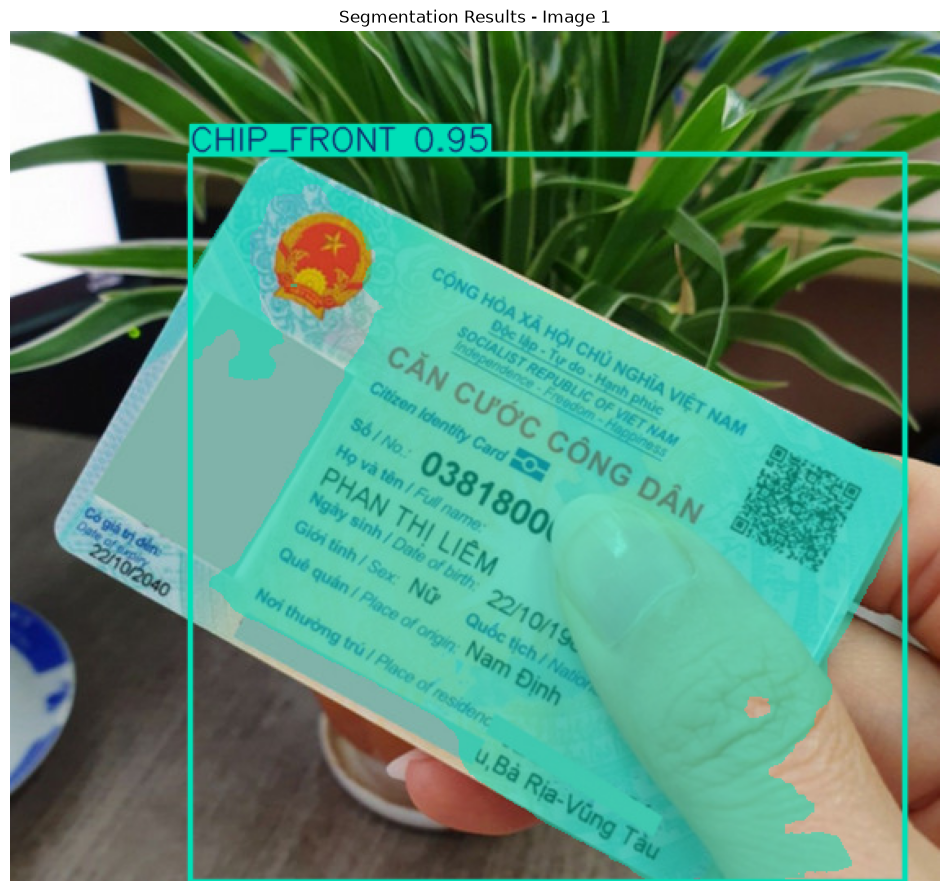

In [4]:
# Run on a sample image from the dataset
sample_image_path = os.path.join(base_dir, "data", "test_seg", "3.jpg")

predict_and_show(sample_image_path)